# تمرین چهارم

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

در این بخش  داده ها خونده میشن و به دو دسته داده تمرین و داده تست تقسیم میکنیم که 320 تا توی داده های تمرین و 80  تا در  داده های تست قرار میگیره<br>
stratify = Y:یعنی از هر شخص 20 درصد عکسا برای تست و بقیه برای تمرین است.

In [2]:
data = fetch_olivetti_faces()
X = data.data
Y = data.target
images = data.images

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y)

print(X_train.shape[0])
print(X_test.shape[0])


320
80


## بخش الف

تعداد کل افراد رو پیدا میکنیم و سپس اونها رو کنار هم نمایش میدیم<br>
شکل ها رو به صورت 5 در 8 نمایش میدیم و جدول کشی کنارش رو خاموش میکنیم و نمایش میدیم

40


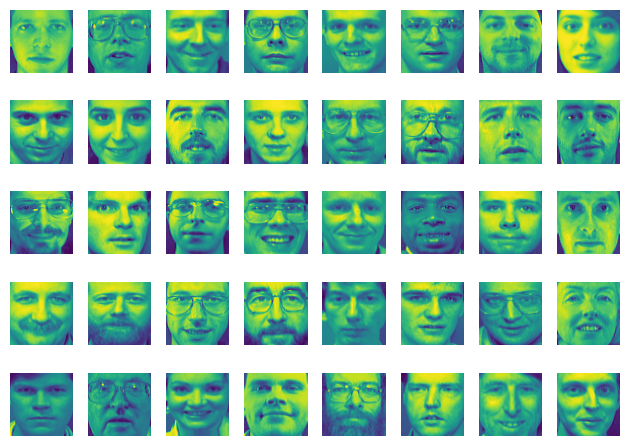

In [3]:
unique_people = np.unique(data.target)
print(len(unique_people))

plt.figure()

for i in range(40):
    person_idx = np.where(data.target == i)[0][0]
    plt.subplot(5, 8, i + 1)
    plt.imshow(data.images[person_idx])
    plt.axis('off')

plt.tight_layout()
plt.show()


## بخش ب

یک مدل مبتنی بر اس وی ام برای شناسایی تصاویر آموزش میدهیم و دقت را گزارش میکنیم

In [4]:
svm_clf = SVC()
svm_clf.fit(X_train, y_train)

y_pred_svm = svm_clf.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {acc_svm}")


SVM Accuracy: 0.975


## بخش ج

همین دقت را با دو مدل رندوم فارست و ادا بوست اندازه میگیریم و با اس وی ام مقایسه میکنیم<br>
بهترین طبق خروجی ها رندوم فارست و سپس اس وی ام است که دقت خوبی داره.ولی ادا بوست دقت خوبی نداره

In [5]:
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

ada_clf = AdaBoostClassifier()
ada_clf.fit(X_train, y_train)
y_pred_ada = ada_clf.predict(X_test)
acc_ada = accuracy_score(y_test, y_pred_ada)

print(f"SVM Accuracy:           {acc_svm}")
print(f"Random Forest Accuracy: {acc_rf}")
print(f"AdaBoost Accuracy:      {acc_ada}")


SVM Accuracy:           0.975
Random Forest Accuracy: 0.975
AdaBoost Accuracy:      0.175


## بخش د

راهکارهای بهبود نتایج:<br>
۱. کاهش ابعاد با تحلیل مولفه‌های اصلی:
<br>
تصاویر این مجموعه داده بیش از چهارهزار ویژگی دارند که حجم بسیار بالایی است. با فشرده‌سازی و استخراج ویژگی‌های کلیدی، می‌توان نویز تصویر و ویژگی‌های کم‌اهمیت را حذف کرد تا هم سرعت پردازش و هم دقت دسته‌بندی به‌طور محسوسی ارتقا یابد.
<br>
۲. تنظیم بهینه متغیرهای مدل:
<br>
با جست‌وجوی ساختاریافته میان تنظیمات مختلف مدل‌ها، مانند تعیین دقیق ضریب خطا و پهنای باند در دسته‌بند بردار پشتیبان یا تنظیم تعداد و عمق درخت‌ها در روش‌های تجمعی، می‌توان بازدهی مدل را به بالاترین حد رساند.
<br>
۳. افزایش و گسترش مصنوعی داده‌ها:
<br>
به دلیل کم بودن تعداد عکس‌های هر شخص، می‌توان با چرخش‌های کوچک، تغییرات اندک در بزرگ‌نمایی، جابه‌جایی زاویه دید و تغییر روشنایی، نمونه‌های مشابه جدیدی ساخت تا توانایی تعمیم‌پذیری مدل در شرایط مختلف چهره بالاتر برود.
